In [1]:
import numpy as np
import  matplotlib.pyplot as plt
from numpy import load
import networkx as nx
import pandas as pd

# Zadanie
Wczytujemy dane i wyjątkowo powiązanych ze sobą substancji oraz grup tychże substancji co jest nie łatwe.

## Jak wyszukiwać substancje ?
Dla przykładu: CIDs00000961
Na tej stronce: https://pubchem.ncbi.nlm.nih.gov/
Wpisujesz 961 i klikasz w pierwszy wynik tam masz wszystkie informacje

## Wczytanie danych

In [2]:
data = pd.read_csv("data/chemical_links.tsv", delimiter='\t')
data

,chemical1,chemical2,similarity,experimental,database,textmining,combined_score
0,CIDm00024759,CIDs00024759,0,0,900,0,900
1,CIDs91758695,CIDs00107694,0,0,0,230,230
2,CIDs91758695,CIDs11013287,0,0,0,230,230
3,CIDs91758695,CIDs11980957,0,0,0,328,328
4,CIDs91758695,CIDs00013078,0,0,0,162,162
...,...,...,...,...,...,...,...
17705813,CIDm00000001,CIDm87081431,753,0,0,173,173
17705814,CIDm00000001,CIDm90857042,0,0,0,218,218
17705815,CIDm00000001,CIDm91056687,0,0,0,294,294
17705816,CIDm00000001,CIDm91213096,0,0,0,357,357


In [3]:
data.columns

Index(['chemical1', 'chemical2', 'similarity', 'experimental', 'database',
       'textmining', 'combined_score'],
      dtype='object')

W kolumnach mamy substancję chemiczną

In [4]:
data.describe

<bound method NDFrame.describe of              chemical1     chemical2  similarity  experimental  database  \
0         CIDm00024759  CIDs00024759           0             0       900   
1         CIDs91758695  CIDs00107694           0             0         0   
2         CIDs91758695  CIDs11013287           0             0         0   
3         CIDs91758695  CIDs11980957           0             0         0   
4         CIDs91758695  CIDs00013078           0             0         0   
...                ...           ...         ...           ...       ...   
17705813  CIDm00000001  CIDm87081431         753             0         0   
17705814  CIDm00000001  CIDm90857042           0             0         0   
17705815  CIDm00000001  CIDm91056687           0             0         0   
17705816  CIDm00000001  CIDm91213096           0             0         0   
17705817  CIDs00024759  CIDm00024759           0             0       900   

          textmining  combined_score  
0             

In [5]:
data.shape

(17705818, 7)

## substancje wchodzące w największą ilość interakcji

In [6]:
G = nx.from_pandas_edgelist(data,
                            source='chemical1',
                            target='chemical2',
                            edge_attr='combined_score')

global_stars = sorted(G.degree(weight='combined_score'), key=lambda x: x[1], reverse=True)

for rank, (node, total_score) in enumerate(global_stars[:5], 1):
    print(f"{rank}. CID: {node} | Całkowita siła powiązań (suma score): {total_score}")

1. CID: CIDs00000961 | Całkowita siła powiązań (suma score): 5586126
2. CID: CIDs00000783 | Całkowita siła powiązań (suma score): 5114671
3. CID: CIDm00000961 | Całkowita siła powiązań (suma score): 4662851
4. CID: CIDm00000783 | Całkowita siła powiązań (suma score): 4091100
5. CID: CIDs00000977 | Całkowita siła powiązań (suma score): 4043600


Dla dalszej części kodu usuwam mało powiązane substancje z powodu tego że jest ich bardzo dużo skupiamy się na tych które są sobie najbliższe jeśli ktoś ma inny pomysł to zachęcam do zmian.

In [7]:
data = data[data['combined_score'] > 900].copy()
data

,chemical1,chemical2,similarity,experimental,database,textmining,combined_score
2215,CIDs91754987,CIDs00060834,0,0,0,917,917
2329,CIDs91754983,CIDs66545760,0,0,0,919,919
4701,CIDs91754246,CIDs00444374,0,0,0,918,918
4743,CIDs91754246,CIDs71295745,0,0,0,969,969
5132,CIDs91754228,CIDs70680429,0,0,0,932,932
...,...,...,...,...,...,...,...
17705484,CIDm00000001,CIDm00000784,0,0,900,210,918
17705493,CIDm00000001,CIDm00000864,0,371,0,875,919
17705509,CIDm00000001,CIDm00000961,0,0,900,189,916
17705513,CIDm00000001,CIDm00000977,0,0,900,530,951


## substancje będące największymi pośrednikami

In [8]:
G = nx.from_pandas_edgelist(data,
                            source='chemical1',
                            target='chemical2',
                            edge_attr='combined_score')

betweenness = nx.betweenness_centrality(G, k=100, seed=42)

top_betweenness = sorted(betweenness.items(), key=lambda item: item[1], reverse=True)

for rank, (node, score) in enumerate(top_betweenness[:5], 1):
    print(f"{rank}. CID: {node} | Współczynnik pośrednictwa: {score:.4f}")

1. CID: CIDs00000961 | Współczynnik pośrednictwa: 0.0352
2. CID: CIDm00000961 | Współczynnik pośrednictwa: 0.0223
3. CID: CIDs00000977 | Współczynnik pośrednictwa: 0.0217
4. CID: CIDs00005957 | Współczynnik pośrednictwa: 0.0122
5. CID: CIDm00000977 | Współczynnik pośrednictwa: 0.0117


In [9]:
data.shape

(110086, 7)

## wykrycie grup
Chcemy znaleźć grupy substancji które ze sobą wchodzą często w interakcję a potem zobaczyć jak interaktują z innymi grupami

In [10]:
communities = nx.community.louvain_communities(G, weight='combined_score')

node_to_group = {}
for group_id, community in enumerate(communities):
    for node in community:
        node_to_group[node] = group_id

data['group1'] = data['chemical1'].map(node_to_group)
data['group2'] = data['chemical2'].map(node_to_group)

inter_group_links = data[data['group1'] != data['group2']]

group_connections = inter_group_links.groupby(['group1', 'group2'])['combined_score'].agg(['count', 'mean', 'sum']).reset_index()

group_connections = group_connections.sort_values(by='sum', ascending=False)

In [11]:
group_connections

,group1,group2,count,mean,sum
73,381,438,505,933.946535,471643
208,438,381,505,933.946535,471643
72,381,437,216,934.185185,201784
201,437,381,216,934.185185,201784
47,381,148,207,934.091787,193357
...,...,...,...,...,...
241,685,381,1,902.000000,902
645,3124,2084,1,902.000000,902
272,1091,435,1,902.000000,902
280,1108,774,1,901.000000,901


## Powiązania z innymi grupami

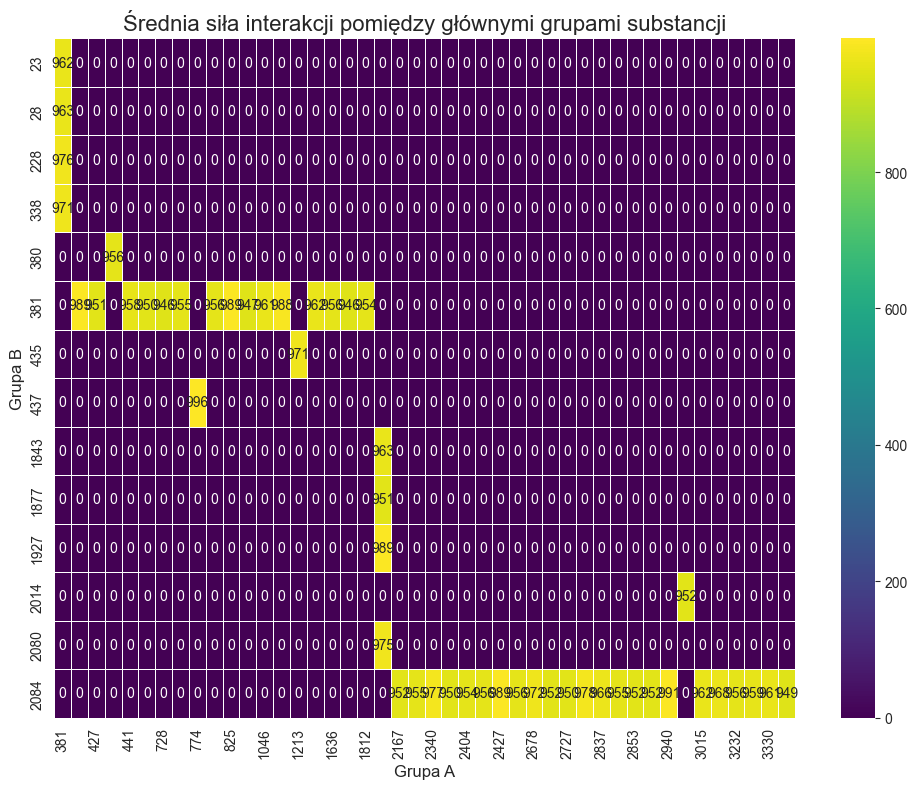

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

inter_group_links = inter_group_links.copy()
inter_group_links['group_A'] = inter_group_links[['group1', 'group2']].min(axis=1)
inter_group_links['group_B'] = inter_group_links[['group1', 'group2']].max(axis=1)

group_connections = inter_group_links.groupby(['group_A', 'group_B'])['combined_score'].agg(['count', 'mean', 'sum']).reset_index()

top_edges = group_connections.sort_values(by='mean', ascending=False).head(50)

pivot_df = top_edges.pivot(index='group_A', columns='group_B', values='mean').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt=".0f", linewidths=.5)
plt.title('Średnia siła interakcji pomiędzy głównymi grupami substancji', fontsize=16)
plt.xlabel('Grupa A', fontsize=12)
plt.ylabel('Grupa B', fontsize=12)
plt.tight_layout()
plt.show()

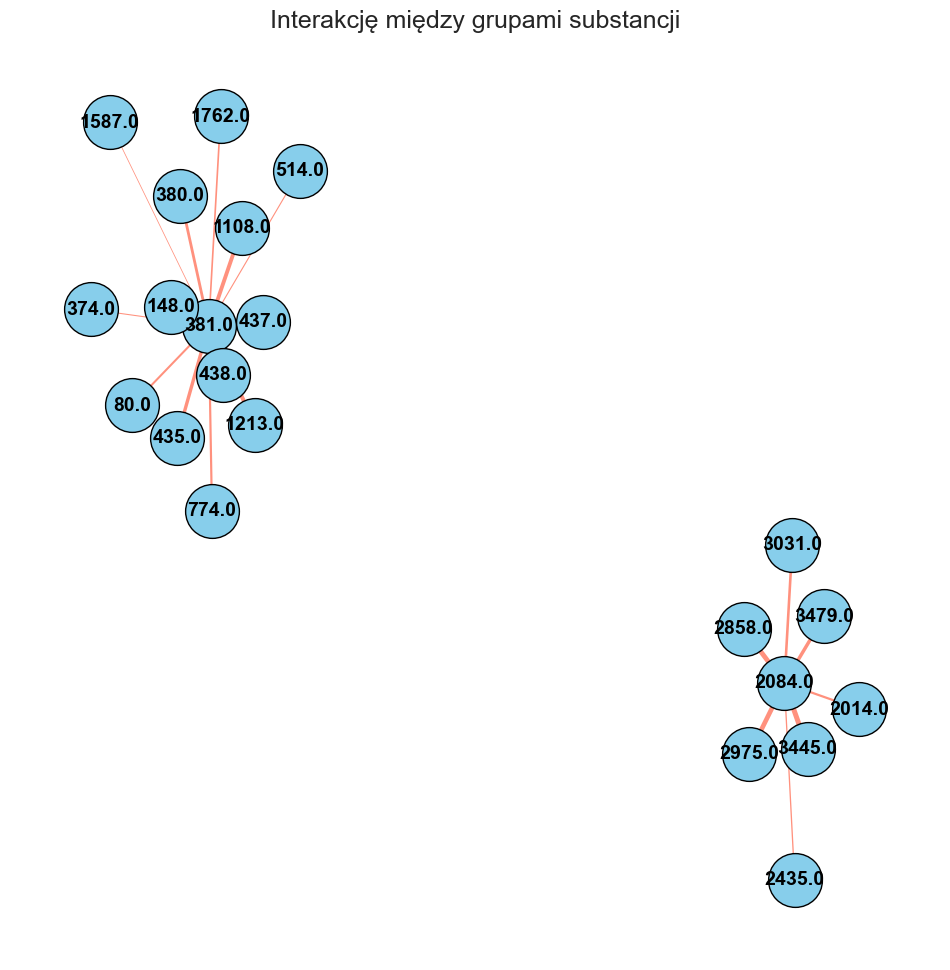

In [13]:
top_super_edges = group_connections.sort_values(by='sum', ascending=False).head(20)

G_super = nx.Graph()

for index, row in top_super_edges.iterrows():
    G_super.add_edge(row['group_A'], row['group_B'], weight=row['sum'])

plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G_super, k=2, seed=42)

weights = [G_super[u][v]['weight'] / G_super.size(weight='weight') * 50 for u, v in G_super.edges()]

# Rysowanie grup
nx.draw_networkx_nodes(G_super, pos, node_size=1500, node_color='skyblue', edgecolors='black')
# Rysowanie grubych linii interakcji
nx.draw_networkx_edges(G_super, pos, width=weights, edge_color='tomato', alpha=0.7)
# Etykiety
nx.draw_networkx_labels(G_super, pos, font_size=14, font_weight='bold')

plt.title('Interakcję między grupami substancji', fontsize=18)
plt.axis('off')
plt.show()

## Konkretne interakcje między grupami


In [16]:
grupa_A = 2084
grupa_B = 2435

interactions_A_B = data[((data['group1'] == grupa_A) & (data['group2'] == grupa_B)) |
                      ((data['group1'] == grupa_B) & (data['group2'] == grupa_A))]

top_interactions = interactions_A_B.sort_values(by='combined_score', ascending=False).head(5)

print(f"--- Top 5 bezpośrednich interakcji między grupami {grupa_A} a {grupa_B} ---")
for index, row in top_interactions.iterrows():
    print(f"CID {row['chemical1']} <---> CID {row['chemical2']} | Pewność (score): {row['combined_score']}")

--- Top 5 bezpośrednich interakcji między grupami 2084 a 2435 ---
CID CIDm00000573 <---> CID CIDm00003977 | Pewność (score): 998
CID CIDm00003977 <---> CID CIDm00000573 | Pewność (score): 998
CID CIDm00091445 <---> CID CIDm00000573 | Pewność (score): 993
CID CIDm00092111 <---> CID CIDm00000573 | Pewność (score): 993
CID CIDm00000573 <---> CID CIDm00091445 | Pewność (score): 993


## Sprawdzenie zawartości grupy

In [15]:
group_id_to_check = 2003

nodes_in_group = communities[group_id_to_check]

print(f"--- GRUPA {group_id_to_check} ---")
print(f"Całkowita liczba substancji w grupie: {len(nodes_in_group)}")

subgraph = G.subgraph(nodes_in_group)

top_nodes = sorted(subgraph.degree(weight='combined_score'), key=lambda x: x[1], reverse=True)

print("\nNajważniejsze substancje w tej grupie to:")
for node, degree_score in top_nodes:
    print(f"CID: {node} | siła powiązań w grupie: {degree_score}")

--- GRUPA 2003 ---
Całkowita liczba substancji w grupie: 3

Najważniejsze substancje w tej grupie to:
CID: CIDm00691952 | siła powiązań w grupie: 1850
CID: CIDm54759153 | siła powiązań w grupie: 933
CID: CIDm01453697 | siła powiązań w grupie: 917
